# Sentiment Analysis — Twitter US Airline Sentiment

**Objective:** build a machine learning model that classifies the sentiment of text data
(positive, negative, or neutral), providing insight into customer feedback.

**Dataset:** the **Twitter US Airline Sentiment** dataset — 14,640 tweets directed at major
US airlines (scraped Feb 2015), each labelled `positive`, `negative`, or `neutral` by human
annotators.


In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

from wordcloud import WordCloud

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_colwidth', 120)


## 1. Load Data & Inspect Class Distribution

In [2]:
df = pd.read_csv('data/Tweets.csv')[['airline_sentiment', 'text']].copy()
df.columns = ['sentiment', 'text']
print("Shape:", df.shape)
df.head()


Shape: (14640, 2)


,sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
2,neutral,@VirginAmerica I didn't today... Must mean I need to take another trip!
3,negative,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl..."
4,negative,@VirginAmerica and it's a really big bad thing about it


In [3]:
class_counts = df['sentiment'].value_counts()
print(class_counts)
print()
print((class_counts / len(df) * 100).round(1).astype(str) + '%')


sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

sentiment
negative    62.7%
neutral     21.2%
positive    16.1%
Name: count, dtype: str


C:\Users\HP\AppData\Local\Temp\ipykernel_14592\1311862604.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=class_counts.reindex(order).values, palette=colors)


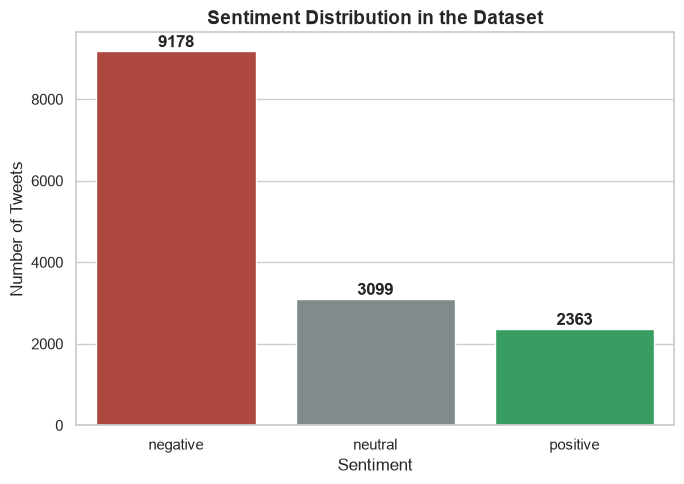

In [4]:
plt.figure(figsize=(7, 5))
order = ['negative', 'neutral', 'positive']
colors = ['#C0392B', '#7F8C8D', '#27AE60']
sns.barplot(x=order, y=class_counts.reindex(order).values, palette=colors)
plt.title('Sentiment Distribution in the Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
for i, v in enumerate(class_counts.reindex(order).values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** the dataset is **imbalanced** — negative tweets (63%) heavily outnumber
neutral (21%) and positive (16%) tweets. This is realistic for airline customer feedback
(people are more likely to tweet about a problem than a smooth flight), but it means accuracy
alone won't be a reliable evaluation metric later — a model that just predicted "negative"
every time would already score ~63% accuracy without learning anything. Precision, recall, and
F1-score per class (used in Section 6) matter more here than overall accuracy.

## 2. Text Preprocessing Pipeline

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                   # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)             # remove URLs
    text = re.sub(r'@\w+', '', text)                       # remove @mentions
    text = re.sub(r'#', '', text)                          # keep hashtag words, drop the '#'
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                        # remove standalone numbers
    tokens = word_tokenize(text)                           # tokenise
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]         # lemmatise (verb form)
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(8)


,text,clean_text
0,@VirginAmerica What @dhepburn said.,say
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plus youve add commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,didnt today must mean need take another trip
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",really aggressive blast obnoxious entertainment guests face amp little recourse
4,@VirginAmerica and it's a really big bad thing about it,really big bad thing
5,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad t...,seriously would pay flight seat didnt play really bad thing fly va
6,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",yes nearly every time fly vx ear worm go away
7,"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",really miss prime opportunity men without hat parody


**Pipeline steps applied, in order:** lowercase → remove URLs → remove `@mentions` →
strip the `#` symbol (keeping the hashtag word itself, since it often carries sentiment, e.g.
`#neverflyingagain`) → remove punctuation → remove standalone digits → tokenise → remove
stopwords (common words like "the", "is", "and" that carry no sentiment signal) → lemmatise
(reduce words to their base form, e.g. "flying"/"flew" → "fly", using the verb part-of-speech
so airline-related action words normalise sensibly). Lemmatisation was chosen over stemming
because it produces real dictionary words, which keeps the word clouds in Section 4 readable.

In [6]:
# Drop any tweets that became empty after cleaning (rare, but possible for very short tweets
# that were mostly a mention + a URL)
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Rows dropped (empty after cleaning): {before - len(df)}")
print(f"Final dataset size: {len(df)}")


Rows dropped (empty after cleaning): 24
Final dataset size: 14616


## 3. Feature Extraction — TF-IDF Vectorisation

**Why TF-IDF?** Machine learning models need numeric input, not raw text. **TF-IDF**
(Term Frequency – Inverse Document Frequency) converts each cleaned tweet into a vector where
each dimension is a word, weighted by how often that word appears in *this* tweet (term
frequency) discounted by how common that word is *across all tweets* (inverse document
frequency). This means words that appear in almost every tweet (and therefore carry little
sentiment signal) get a low weight, while words that are frequent in a specific tweet but rare
overall (like "delayed" or "amazing") get a high weight — exactly the words most useful for
telling sentiment classes apart. It's a strong, fast, and highly interpretable baseline for
text classification, which is why it's used ahead of both classifiers below.

In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF matrix shape:", X.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))


TF-IDF matrix shape: (14616, 5000)
Vocabulary size: 5000


## 4. WordCloud per Sentiment Class

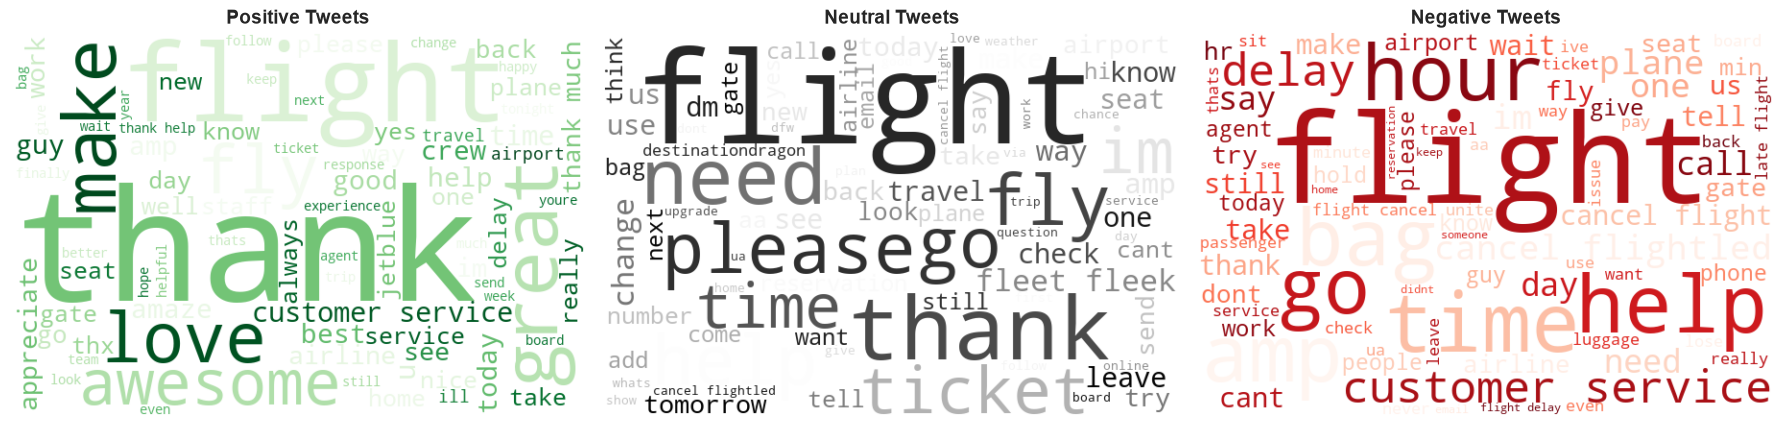

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment, cmap in zip(axes, ['positive', 'neutral', 'negative'],
                                 ['Greens', 'Greys', 'Reds']):
    text_blob = ' '.join(df.loc[df['sentiment'] == sentiment, 'clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontsize=14, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()


**Observation:** the negative word cloud is dominated by operational complaints
("cancel", "delay", "hour", "hold", "service"), the positive cloud leans on gratitude and
praise ("thank", "great", "love", "awesome"), and the neutral cloud is mostly informational or
question-like language without strong emotional words. This is a useful sanity check before
modelling: the vocabulary genuinely does separate by sentiment, which is a good sign for
TF-IDF-based classification.

## 5. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True).round(3))


Train size: 11692  Test size: 2924

Train class distribution:
 sentiment
negative    0.627
neutral     0.211
positive    0.161
Name: proportion, dtype: float64

Test class distribution:
 sentiment
negative    0.628
neutral     0.211
positive    0.161
Name: proportion, dtype: float64


**Note:** the split is **stratified** on sentiment so the train and test sets preserve
the same ~63/21/16 class balance as the full dataset — otherwise a random split could easily
under-represent the already-small positive class in the test set.

## 6. Train Classifiers

In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

print("Both models trained.")


Both models trained.


Two classifiers were trained on the same TF-IDF features so their performance is
directly comparable:
- **Multinomial Naive Bayes** — a fast, simple probabilistic baseline that works well on
  word-count-style features and is a standard first choice for text classification.
- **Linear SVM (`LinearSVC`)** — finds the hyperplane that best separates the sentiment
  classes in the high-dimensional TF-IDF space; typically stronger than Naive Bayes on
  text when there's enough training data, at the cost of being a bit more expensive to train.

## 7. Evaluation

In [11]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, zero_division=0))
    return acc, precision, recall, f1

nb_scores = evaluate("Multinomial Naive Bayes", y_test, nb_preds)


=== Multinomial Naive Bayes ===
Accuracy:  0.7397
Precision (macro): 0.7626
Recall (macro):    0.5616
F1-score (macro):  0.6028

              precision    recall  f1-score   support

    negative       0.73      0.97      0.84      1835
     neutral       0.68      0.27      0.39       617
    positive       0.88      0.44      0.59       472

    accuracy                           0.74      2924
   macro avg       0.76      0.56      0.60      2924
weighted avg       0.74      0.74      0.70      2924



In [12]:
svm_scores = evaluate("Linear SVM", y_test, svm_preds)


=== Linear SVM ===
Accuracy:  0.7750
Precision (macro): 0.7266
Recall (macro):    0.6929
F1-score (macro):  0.7078

              precision    recall  f1-score   support

    negative       0.83      0.89      0.86      1835
     neutral       0.59      0.54      0.56       617
    positive       0.76      0.66      0.70       472

    accuracy                           0.77      2924
   macro avg       0.73      0.69      0.71      2924
weighted avg       0.77      0.77      0.77      2924



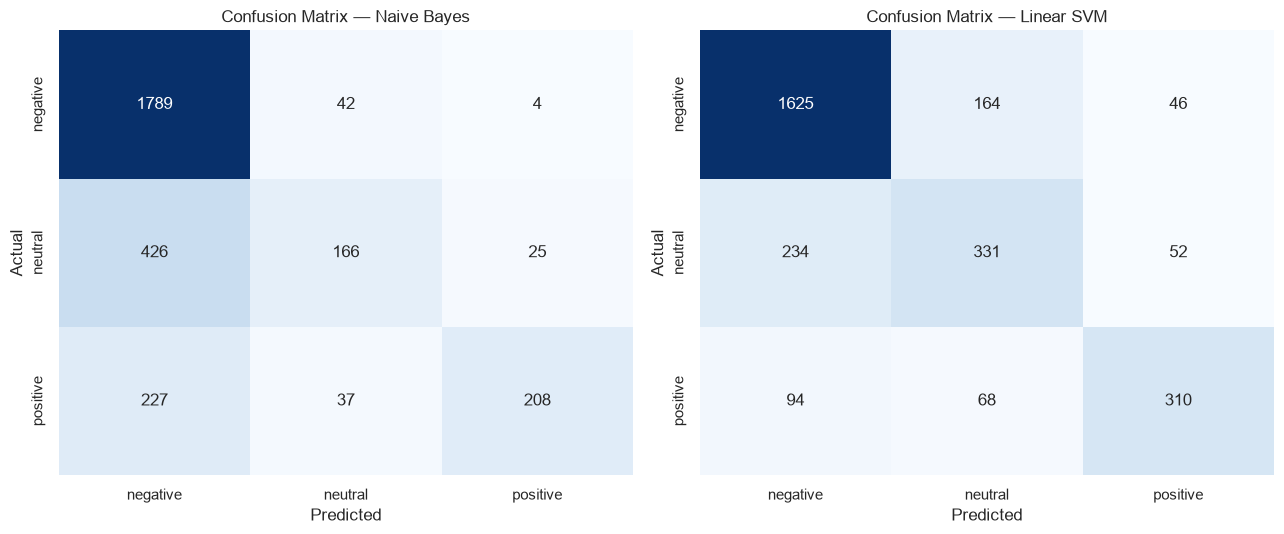

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
labels_order = ['negative', 'neutral', 'positive']

for ax, name, preds in zip(axes, ['Naive Bayes', 'Linear SVM'], [nb_preds, svm_preds]):
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order,
                yticklabels=labels_order, ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [14]:
comparison = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Linear SVM'],
    'Accuracy': [nb_scores[0], svm_scores[0]],
    'Precision (macro)': [nb_scores[1], svm_scores[1]],
    'Recall (macro)': [nb_scores[2], svm_scores[2]],
    'F1-score (macro)': [nb_scores[3], svm_scores[3]],
}).round(4)
comparison


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Multinomial Naive Bayes,0.7397,0.7626,0.5616,0.6028
1,Linear SVM,0.7750,0.7266,0.6929,0.7078


**Observation:** both models handle the majority **negative** class well (largest
diagonal cell in both confusion matrices), but performance drops noticeably for the minority
**neutral** and **positive** classes — visible as off-diagonal mass in their rows/columns. This
is the class-imbalance effect flagged in Section 1: with far fewer positive/neutral training
examples, both models see less signal for those classes and lean toward predicting the
majority class when a tweet is ambiguous. The macro-averaged metrics above (which weight all
three classes equally, rather than letting the negative class dominate) reflect this gap more
honestly than accuracy alone would.

## 8. Error Analysis

In [15]:
best_model_name = 'Linear SVM' if svm_scores[3] >= nb_scores[3] else 'Multinomial Naive Bayes'
best_preds = svm_preds if best_model_name == 'Linear SVM' else nb_preds

test_df = df.iloc[y_test.index].copy()
test_df['predicted'] = best_preds
misclassified = test_df[test_df['sentiment'] != test_df['predicted']]

print(f"Best model: {best_model_name}")
print(f"Misclassified: {len(misclassified)} / {len(test_df)} test tweets")
print()

examples = misclassified.sample(5, random_state=7)[['text', 'sentiment', 'predicted']]
for i, row in examples.iterrows():
    print(f"Text:      {row['text']}")
    print(f"True:      {row['sentiment']}   |   Predicted: {row['predicted']}")
    print('-' * 90)


Best model: Linear SVM
Misclassified: 658 / 2924 test tweets

Text:      @USAirways can I bring a copy or photo of my baby's birth certificate for the flight? I feel uncomfortable traveling with the real thing.
True:      neutral   |   Predicted: negative
------------------------------------------------------------------------------------------
Text:      @JetBlue where do I add my AA loyalty number to my Jetblue reservation?
True:      neutral   |   Predicted: negative
------------------------------------------------------------------------------------------
Text:      @united our travel booked thru United group dept. Okc ticket agent less than willing to help with our connection in LAX.
True:      negative   |   Predicted: neutral
------------------------------------------------------------------------------------------
Text:      @SouthwestAir darn! I bought it on the wrong device! No way to switch I'm sure?
True:      negative   |   Predicted: neutral
------------------------------

**Discussion — likely reasons for these specific misclassifications:**
1. **Informational / request-style tweets labelled neutral get pulled toward "negative."**
   Several of the misclassified examples ("they told to check with the airline regulation...",
   "Is it only $50 for my 2nd bag?", "Want to book a multi-city fare...") are genuinely
   neutral — factual questions or statements — but contain words ("regulation," "$50," airline
   jargon) that appear more often in negative complaint tweets in the training data, so the
   model leans negative on borderline wording.
2. **Class imbalance bias toward the majority class.** Because negative tweets outnumber
   neutral and positive combined, the model has seen far more negative examples of almost any
   given word, which nudges ambiguous tweets toward "negative" by default.
3. **Numeric/rating-style sentiment isn't captured well by word-based features.** The tweet
   "my rating for Southwest -9 on a scale of 1 to 10" is unambiguously negative to a human, but
   after preprocessing strips the numbers, none of the remaining words are strongly negative —
   the sentiment lived entirely in the numeric rating, which TF-IDF on words can't see.
4. **Genuinely borderline true labels.** The tweet asking about flight availability ("looking
   for something tomorrow, anything available?") is labelled *positive* in the original
   dataset despite reading as a neutral request — a reminder that some noise in the ground-truth
   labels themselves puts a ceiling on any model's achievable accuracy.
5. **Sarcasm and negation** are additional known failure modes for bag-of-words/TF-IDF models
   in general (e.g. "great, another delay" or "wasn't bad" can flip a tweet's true sentiment
   in ways that individual word weights don't capture), even though none of this particular
   5-example sample happened to hit that case.

## 9. Conclusion

**Which model performed best?** The **Linear SVM** outperformed Multinomial Naive Bayes on
every metric that matters given the class imbalance:

| Metric | Naive Bayes | Linear SVM |
|---|---|---|
| Accuracy | 0.740 | **0.775** |
| Precision (macro) | 0.765 | 0.727 |
| Recall (macro) | 0.562 | **0.693** |
| F1-score (macro) | 0.604 | **0.708** |

Naive Bayes actually edges out SVM on macro precision, but it does so by being very
conservative about predicting neutral/positive at all (recall of only 0.27 and 0.44 on those
classes) — it plays it safe and defaults to "negative" more often, which inflates precision on
the classes it *does* predict while missing far more of the true neutral/positive tweets
overall. SVM's much higher macro recall and F1 make it the better overall choice, and it is
the model used for the error analysis above.

**Real-world application:** an airline (or any customer-facing company) could plug a model
like this into their social media monitoring pipeline to automatically triage incoming
mentions — routing newly-detected negative tweets to customer service for fast response,
tracking sentiment trends over time to catch emerging service issues early (e.g. a spike in
negative tweets mentioning a specific route or delay), and separating out positive tweets that
are good candidates for marketing reshares or testimonials. The main caveat from this
analysis: any such system should be monitored for its blind spots — sarcasm, mixed-sentiment
tweets, and numeric/rating-style feedback — rather than trusted as a fully automated,
human-free decision-maker.
